#### `Image Denoising with Wavelets`
*Important:* Please read the [installation page](http://gpeyre.github.io/numerical-tours/installation_python/) 

Ce notebook utilise les ondelettes pour réaliser un débruitage d’image non linéaire.

In [9]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from nt_solutions.denoisingwav_2_wavelet_2d import exo1

Image Denoising 
----------------
On considère un modèle génératif simple d’images bruitées $F = f_0+W$ où $f_0 \in \mathcal{R}^N$ est une image déterministe de $N$ pixels, et $W$ un bruit blanc gaussien distribué selon $\mathcal{N}(0,\sigma^2 \text{I}_N)$, où $\sigma^2$ est la variance du bruit.

L’objectif du débruitage est de définir un estimateur $\tilde F$ of $f_0$ qui ne dépend que de $F$, c’est‑à‑dire $\tilde F = \phi(F)$ where $\phi : \mathcal{R}^N \rightarrow \mathcal{R}^N$ est une application potentiellement non linéaire.

On remarque que, tandis que $f_0$ est une image déterministe, $F$ and $\tilde F$ sont tous deux des variables aléatoires (d’où l’usage des lettres capitales).

Le but du débruitage est de réduire autant que possible l’erreur de débruitage en utilisant certaines connaissances a priori sur l’image (inconnue) $f_0$.

Une manière mathématique de mesurer cette erreur est de majorer le risque quadratique $\mathcal{E}_w(||{\tilde F - f_0}||^2)$, où l’espérance est prise par rapport à la loi du bruit $W$.

#### `Chargement de l’image et ajout de bruit gaussien`
Pour les applications réelles, on n’a pas accès à l’image sous‑jacente $f_0$. Dans ce tour, nous supposons cependant que $f_0$ est connue, et que $f = f_0 + w\in \mathcal{R}^N$ est générée à partir d’une seule réalisation du bruit $w$ ttirée de $W$. Nous définissons l’image déterministe estimée par $\tilde f = \phi(f)$ qui est une réalisation du vecteur aléatoire $\tilde F$.

Nous commençons par charger une image $f \in \mathcal{R}^N$ où $N=n \times n$ est le nombre de pixels.

In [7]:
n = 256
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/hibiscus.bmp'
f0 = load_image(name, n)
print(f0.shape)
# normalise l'image, pour l’affichage et les paramètres (bruit, λ, etc.).
f0 = rescale(f0)

(256, 256)


In [8]:
def snr(f0, f_denoise):
    num = np.linalg.norm(f0)             # ||f0||
    den = np.linalg.norm(f0 - f_denoise) # ||f0 - fsob||
    return 20 * np.log10(num/den)

 - Nous ajoutons un bruit Gaussian $w$ pour obtenir $f=f_0+w$ de variance $\sigma$.
 - Afficher l'image bruitée. 
 - Utiliser |clamp| pour saturer le résultat $[0,1]$ et éviter une perte du contraste à l'affichage.

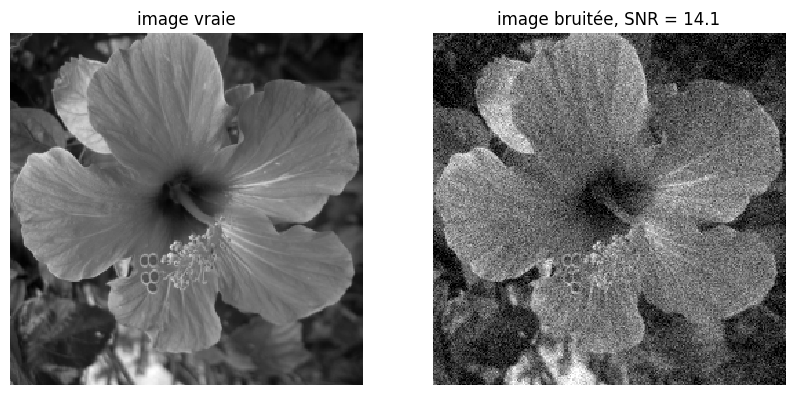

In [10]:
sigma = .08
y = f0 + np.random.randn(n, n)*sigma
plt.figure(figsize=(10, 10))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(y),f"image bruitée, SNR = {snr(f0,y):.3g}" , [1,2,2])

#### `Seuillage dur dans des bases d’ondelettes`
Un estimateur de débruitage non linéaire simple mais efficace s’obtient en seuillant les coefficients de $f$ dans une base orthogonale bien choisie $\mathcal{B} = \{\psi_m\}_m$ of $\mathcal{R}^N$.

Dans la suite, nous nous concentrons sur une base d’ondelettes, qui est efficace pour débruiter des images par morceaux régulières.

L’opérateur de seuillage dur de seuil $T \geq 0$ appliqué à une image  $f$ est défini par :  
$$S_T^0(f)=\sum_{|\langle{f},{\psi_m}\rangle|>T}{f}{\psi_m}\psi_m = \sum_m s_T^0(\langle{f},{\psi_m}\rangle) \psi_m$$
 - où l’opérateur de seuillage dur scalaire est is : $ w_{j,k}^{(\text{seuil})} = \left\{ \begin{array}{ll}  \alpha  \text{ si } |\alpha| \ge T\\ 0 \text{ sinon } \end{array} \right.$

L’estimateur de débruitage est alors défini par : $ \tilde f = S_T^0(f). $


Fixer la valeur du seuil et afficher la fonction $s_T^0(\alpha)$.

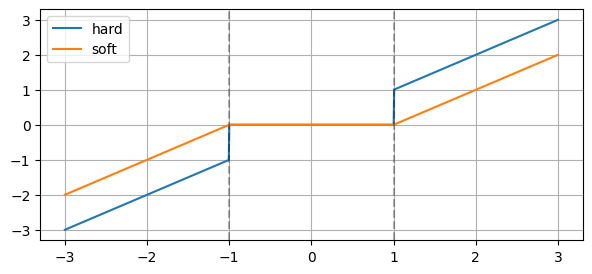

In [44]:
import numpy as np
import matplotlib.pyplot as plt

T = 1.0
alpha = np.linspace(-3, 3, 1000)

# Seuillage dur
hard = alpha * (np.abs(alpha) > T)

# Seuillage doux
# np.maximum : maximum élément par élément entre deux tableaux (ou tableau + scalaire).
soft = np.sign(alpha) * np.maximum(np.abs(alpha) - T, 0)

plt.figure(figsize=(7,3))
plt.plot(alpha, hard, label="hard")
plt.plot(alpha, soft, label="soft")
plt.axvline(T, color="k", ls="--", alpha=0.3)
plt.axvline(-T, color="k", ls="--", alpha=0.3)
plt.axis("tight")
plt.grid(True)
plt.legend()
plt.show()


- Paramètre pour la transformation orthogonal en ondelettes 
 - Calculer premièrement les coefficients en ondelettes de l'image bruitée $y$.

In [51]:
import pywt
import numpy as np
# Transformée décimée (options.ti = 0)
# y : signal ou image
# Jmin : niveau minimal
# J : niveau maximal (par ex. J = Jmin + 1 comme dans ton appel MATLAB)
Jmin = 4
# wavelet='dbN', 'symN', 'haar'
wavelet = 'db2'  # par ex., à adapter à ce que fait options.wavelet
# 1D : f is 1D array
coeffs_ti_1d = pywt.wavedec(y, wavelet=wavelet, level=Jmin+1)
# reconstruction correspondante
y_rec_1d = pywt.waverec(coeffs_ti_1d, wavelet=wavelet)
# 2D image : f is 2D array
coeffs_ti_2d = pywt.wavedec2(y, wavelet=wavelet, level=Jmin+1)
# reconstruction correspondante
y_rec_2d = pywt.waverec2(coeffs_ti_2d, wavelet=wavelet)

Les coefficients d’ondelettes sont juste des produits scalaires entre ton signal et des “briques” de base (ondelettes et fonctions d’échelle).
1. Ce que représente un coefficient
Pour chaque échelle j et position k :
- $\phi_{J,k}(t)$ : une fonction d’échelle (low-pass) centrée près de la position k, à l’échelle grossière J.
- $\psi_{j,k}(t)$ : une ondelette (petite oscillation localisée) à l’échelle j et position k.

Dans la DWT 1D, les coefficients obtienus ont pour signification : coeffs = [cA_J, cD_J, cD_{J-1}, ..., cD_1]
coeffs = [cA_J, cD_J, cD_{J-1}, ..., cD_1]

- cA_J : coefficients d’approximation au niveau le plus grossier J. Ce sont les projections du signal sur les fonctions d’échelle (low-pass), donc le contenu “lent”, les grandes structures / tendance globale.

- cD_j : coefficients de détail au niveau j. Ce sont les projections sur les ondelettes à l’échelle $2^j$, donc le contenu “rapide” autour de cette échelle : variations locales, détails, singularités.

Intuition par niveau :
- cD_1 : détails les plus fins (hautes fréquences, bruit, petits bords).
- cD_2 : un peu plus grossier, etc.
- cD_J : détails relativement grossiers, structures un peu plus larges.
- cA_J : ce qui reste après avoir filtré tous ces détails, une version très lissée du signal.

Mathématiquement, tu as une décomposition du type : $f(t) = \sum_{k} cA_J[k]\,\phi_{J,k}(t) + \sum_{j=1}^{J} \sum_{k} cD_j[k]\,\psi_{j,k}(t)$
 - où $\phi_{J,k}$ sont les fonctions d’échelle et $\psi_{j,k}$ les ondelettes.
 - Le premier bloc que tu concatènes correspond à cA_J (approximation grossière).
 - Les blocs suivants sont cD_1, cD_2, ..., cD_J (détails de plus en plus grossiers si tu les remets dans cet ordre).

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def plot_wavelet_1d(coeffs):
    """
    coeffs : liste [cA_J, cD_J, ..., cD_1] telle que renvoyée par pywt.wavedec
    (transformée décimée 1D, pas swt)
    """
    # conversion en 1D
    coeffs_1d = [np.ravel(c) for c in coeffs]

    cA_J, *details = coeffs_1d
    details = details[::-1]  # [cD_1, ..., cD_J]

    blocs = [cA_J] + details
    x = np.concatenate(blocs)

    pos = 0
    for b in blocs[:-1]:
        pos += len(b)
        plt.axvline(pos, color='r', linestyle='--', linewidth=0.5)

    plt.plot(x)
    plt.axis('tight')

Display the noisy coefficients.

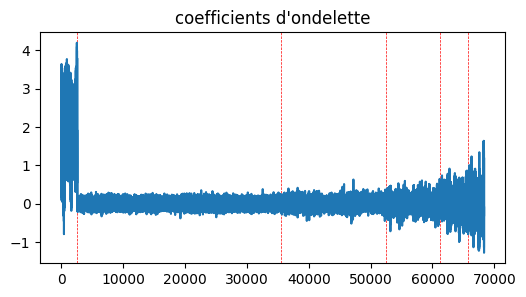

In [56]:
plt.figure(figsize=(6,3))
plot_wavelet_1d(coeffs_ti_1d)
plt.title("coefficients d'ondelette")
plt.show()

In [57]:
import matplotlib.pyplot as plt

def plot_wavelet_2d(coeffs):
    """
    coeffs : [cA_J, (cH_J, cV_J, cD_J), ..., (cH_1, cV_1, cD_1)]
    comme renvoyé par pywt.wavedec2
    """
    cA_J = coeffs[0]
    details = coeffs[1:]  # liste de tuples (cH_j, cV_j, cD_j)

    n_levels = len(details)

    fig, axes = plt.subplots(n_levels + 1, 4, figsize=(10, 2.5*(n_levels+1)))
    # première ligne : approximation
    ax = axes[0, 0]
    im = ax.imshow(cA_J, cmap="gray")
    ax.set_title("cA_J")
    ax.axis("off")
    for j in range(1, 4):
        axes[0, j].axis("off")

    # lignes suivantes : détails par niveau
    for i, (cH, cV, cD) in enumerate(details, start=1):
        for ax, img, title in zip(axes[i], [cH, cV, cD, None],
                                  ["cH", "cV", "cD", ""]):
            ax.axis("off")
            if img is not None:
                ax.imshow(img, cmap="gray")
                ax.set_title(f"{title}_{n_levels-i+1}")

    plt.tight_layout()
    return fig


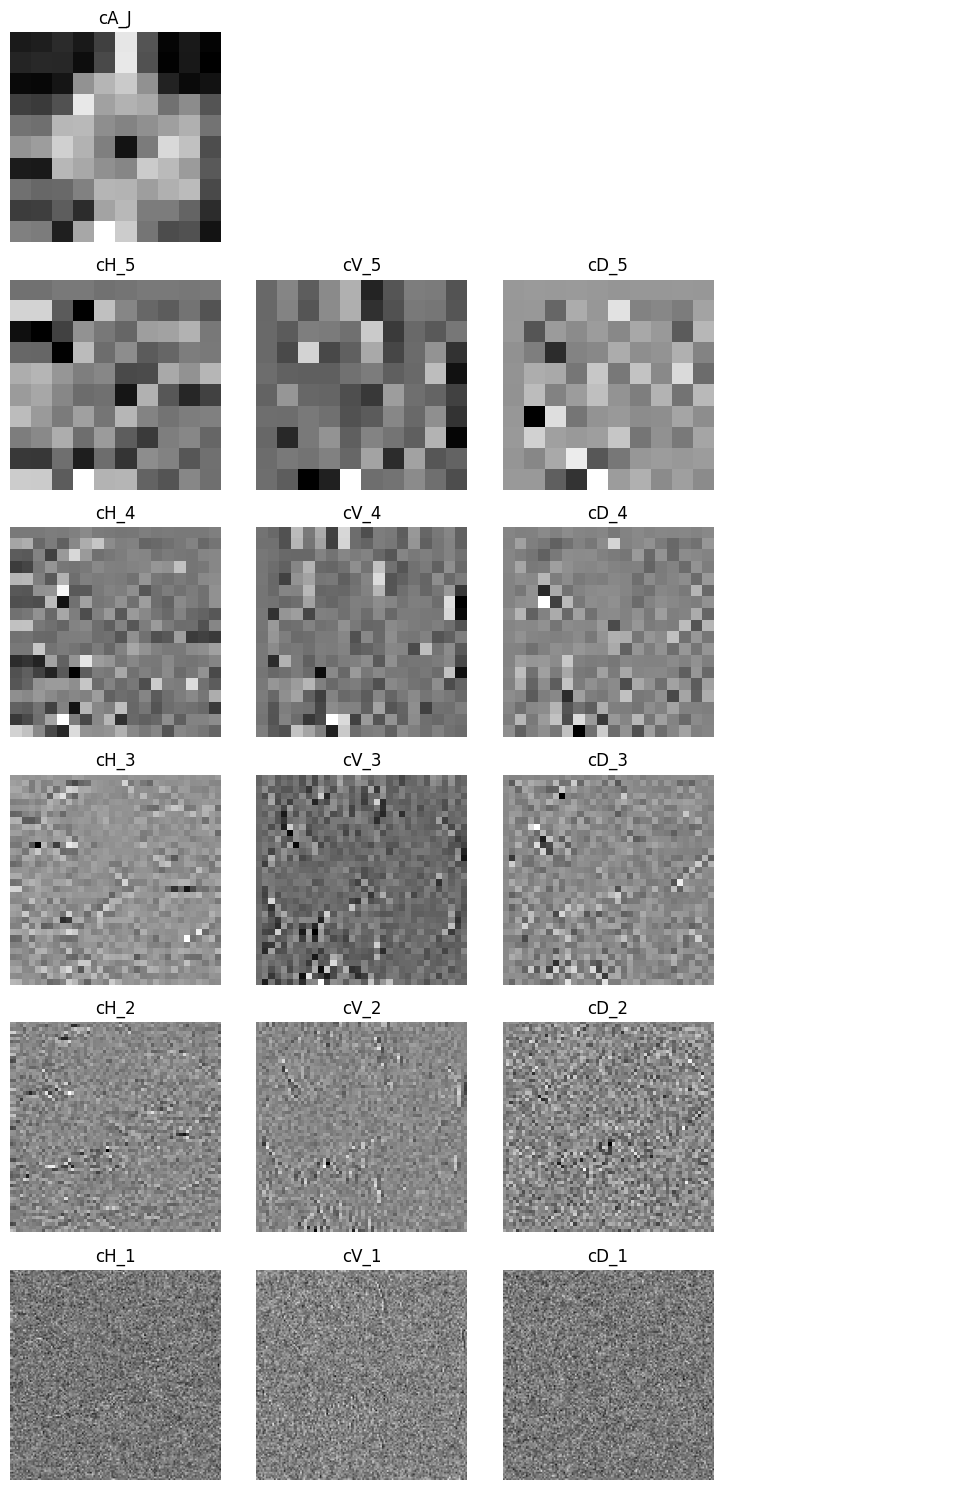

In [58]:
coeffs2 = pywt.wavedec2(y, wavelet="db2", level=Jmin+1)
plot_wavelet_2d(coeffs2)
plt.show()

Select the threshold value, that should be proportional to the noise
level $\si$.

In [ ]:
T = 3*sigma

Hard threshold the coefficients below the noise level to obtain $a_T(m)=s_T^0(a_m)$.

In [ ]:
aT = a .* (abs(a) >T)

Display the thresholded coefficients.

In [ ]:
plot_wavelet(aT, Jmin)

Reconstruct the image $\tilde f$ from these noisy coefficients.

In [ ]:
fHard = perform_wavelet_transf(aT, Jmin, -1, options)

Display the denoising result.

In [ ]:
imageplot(clamp(fHard), strcat(['Hard denoising, SNR = ' num2str(snr(f0, fHard), 3)]))

Wavelet Denoising with Soft Thesholding
---------------------------------------
The estimated image $\tilde f$ using hard thresholding.
suffers from many artifacts. It is
possible to improve the result by using soft thresholding,
defined as
$$ \tilde f = S_T^1(f) = \sum_m s_T^1(\dotp{f}{\psi_m}) \psi_m $$
$$
      \qwhereq
      s_T^1(\alpha) = \max\pa{0, 1 - \frac{T}{\abs{\alpha}}}\alpha.
$$



Display the soft thresholding function $s_T^1(\al)$.

In [ ]:
T = 1
alpha = linspace(-3, 3, 1000)
alphaT = max(1-T./ abs(alpha), 0).*alpha

plot(alpha, alphaT)
axis tight

Select the threshold.

In [ ]:
T = 3/ 2*sigma

Perform the soft thresholding.

In [ ]:
aT = perform_thresholding(a, T, 'soft')

To slightly improve the soft thresholding performance, we do not
threshold the coefficients corresponding to coarse scale wavelets.

In [ ]:
aT(1: 2^Jmin, 1: 2^Jmin) = a(1: 2^Jmin, 1: 2^Jmin)

Re-construct the soft thresholding estimator $\tilde f$.

In [ ]:
fSoft = perform_wavelet_transf(aT, Jmin, -1, options)

Display the soft thresholding denoising result.

In [ ]:
imageplot(clamp(fSoft), strcat(['Soft denoising, SNR = ' num2str(snr(f0, fSoft), 3)]))

One can prove that if the non-linear approximation error
$ \norm{f_0-S_T(f_0)}^2 $ decays fast toward zero when
$T$ decreases, then the quadratic risk
$ \EE_w( \norm{f-S_T(f)}^2 ) $ also decays fast to zero
when $\si$ decays. For this result to hold, it is required
to select the threshold value according to the universal threshold rule
$$ T = \si \sqrt{2\log(N)}. $$

__Exercise 1__

Determine the best threshold $T$ for both hard and soft thresholding.
Test several $T$ values in $[.8*\sigma, 4.5\sigma$,
and display the empirical SNR $-10\log_{10}(\norm{f_0-\tilde f}/\norm{f_0})$
What can you conclude from these results ?
Test with another image.

In [ ]:
solutions.exo1()

In [ ]:
## Insert your code here.

Translation Invariant Denoising with Cycle Spinning
---------------------------------------------------
Orthogonal wavelet transforms are not translation invariant.
It means that the processing of an image and of a translated version of
the image give different results.


Any denoiser can be turned into a translation invariant denoiser by
performing a cycle spinning. The denoiser is applied to several shifted
copies of the image, then the resulting denoised image are shifted back
to the original position, and the results are averaged.


This corresponds to defining the estimator as
$$ \tilde f = \frac{1}{M} \sum_{i=1}^{M}
      T_{-\de_i} \circ S_T(f) \circ T_{\de_i}$$
where $S_T$ is either the hard or soft thresholding,
and $T_\de(f)(x) = f(x-\de)$ is the translation operator,
using periodic boundary conditions.
Here $(\de_i)_i$ is a set of $M$ discrete translation. Perfect invariance
is obtained by using all possible $N$ translatation, but
usually a small number $M \ll N$ of translation is used to obtain approximate
invariance.



Number $m$ of translations along each direction
so that $M = m^2$.

In [ ]:
m = 4

Generate a set of shifts $(\de_i)_i$.

In [ ]:
[dY, dX] = meshgrid(0: m-1, 0: m-1)
delta = [dX(: ) dY(: )]'

To avoid storing all the translates in memory, one can perform a
progressive averaging of the translates by defining $f^{(0)}=0$ and
then
$$ \forall\, i=1,\ldots,M, \quad f^{(i)} = \pa{1-\frac{i}{n}} f^{(i-1)} +
      \frac{i}{n} T_{-\de_i} \circ S_T(f) \circ T_{\de_i}  $$
One then has $\tilde f = f^{(M)} $ after $M$ steps.


Initialize the denoised image $f^{(0)}=0$.

In [ ]:
fTI = zeros(n, n)

Initialize the index $i$ that should run in $1,\ldots,m^2$

In [ ]:
i = 1

Apply the shift, using circular boundary conditions.

In [ ]:
fS = circshift(f, delta(: , i))

Apply here the denoising to |fS|.

In [ ]:
a = perform_wavelet_transf(fS, Jmin, 1, options)
aT = perform_thresholding(a, T, 'hard')
fS = perform_wavelet_transf(aT, Jmin, -1, options)

After denoising, do the inverse shift.

In [ ]:
fS = circshift(fS, -delta(: , i))

Accumulate the result to obtain at the end the denoised image that
averahe the translated results.

In [ ]:
fTI = (i-1)/ i*fTI + 1/ i*fS

__Exercise 2__

Perform the cycle spinning denoising by iterating on $i$.

In [ ]:
solutions.exo2()

In [ ]:
## Insert your code here.

__Exercise 3__

Study the influence of the number $m$ of shift on the denoising
quality.

In [ ]:
solutions.exo3()

In [ ]:
## Insert your code here.

Translation Invariant Wavelet Transform
---------------------------------------
Another way to achieve translation invariance, which is equivalent to
performing cycle spinning, is to replace the orthogonal wavelet
basis $\Bb = \{\psi_m\}_{m=0}^{N-1}$ by a redundant translation
invariant wavelet frame
$$ \Dd = \enscond{ \psi_m(\cdot-\de) }{ m = 0,\ldots,N-1, \de \in \{0,\ldots,n-1\}^2 }. $$


One can prove that there is actually only $P = N\log_2(N)$ atoms in this
dictionary, that we note $\De = \{\tilde \psi_k\}_{k=0}^{P-1}$.


One can furthermore define weights $\la_k>0$ so that the
following reconstruction formula holds (pseudo-invers reconstruction)
$$ f = \sum_k \la_k \dotp{f}{\tilde \psi_k} \tilde \psi_k. $$


For Scilab, we need to extend a little the available memory.


_Important:_ If you are using an old version (<v5)
of Scilab, then use |extend_stack_size(4,1)| instead.

In [ ]:
extend_stack_size(4)

The invariant transform is obtained using the same function, by
activating the switch |options.ti=1|.

In [ ]:
options.ti = 1
a = perform_wavelet_transf(f0, Jmin, + 1, options)

|a(:,:,1)| corresponds to the low scale residual.
Each |a(:,:,3*j+k+1)| for k=1:3 (orientation) corresponds to a scale of wavelet coefficient, and has
the same size as the original image.

In [ ]:
i = 0
for j in 1: 2:
for k in 1: 3:
        i = i + 1
        imageplot(a(: , : , i + 1), strcat(['Scale = ' num2str(j) ' Orientation = ' num2str(k)]), 2, 3, i)

Translation Invariant Wavelet Denoising
---------------------------------------
A translation invariant thresholding estimator is defined as
$$ \tilde f = \sum_k \la_k s_T(\dotp{f}{\tilde \psi_k}) \tilde \psi_k, $$
where $s_T$ is either the soft or the hard thresholding mapping.


This estimator is equal to the cycle spinning estimator when using the
full set $M=N$ of translates. It is however much faster to compute
because computing the whole set of $N\log_2(N)$ inner products $(\dotp{f}{\tilde\psi_k})_k$
is obtained with the fast a trou algorithm in $O(N\log_2(N))$
operations.
Similarely, a fast inverse transform with the same complexity allows one
to reconstruct $\tilde f$ from the set of thresholded coefficients.


First we compute the translation invariant wavelet transform

In [ ]:
options.ti = 1
a = perform_wavelet_transf(f, Jmin, + 1, options)

Then we threshold the set of coefficients.

In [ ]:
T = 3.5*sigma
aT = perform_thresholding(a, T, 'hard')

Display noisy wavelets coefficients at a given fixed scale.

In [ ]:
J = size(a, 3)-5

imageplot(a(: , : , J), 'Noisy coefficients')

Display thresholded wavelets coefficients

In [ ]:
imageplot(aT(: , : , J), 'Thresholded coefficients')

We can now reconstruct

In [ ]:
fTI = perform_wavelet_transf(aT, Jmin, -1, options)

Display the denoising result $\tilde f$.

In [ ]:
imageplot(clamp(fTI), strcat(['Hard invariant, SNR = ' num2str(snr(f0, fTI), 3)]))

__Exercise 4__

Determine the best threshold $T$ for both hard and soft thresholding,
but now in the translation invariant case. What can you conclude ?

In [ ]:
solutions.exo4()

In [ ]:
## Insert your code here.